In [101]:
import json
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import seaborn as sns
import sys
from collections import defaultdict
from pathlib import Path

sys.path.insert(0, '/home/sagemaker-user/compliance')
from compliance_utils import print_color

FOLDER_HOME: Path = Path('/home/sagemaker-user')
FOLDER_JUDGED_SCENARIOS: Path = FOLDER_HOME / 'data/judged_scenarios/'
FOLDER_JUDGED_SCENARIOS_CSV: Path = FOLDER_JUDGED_SCENARIOS / 'csv/'

In [102]:
def extract_model_from_filename(filename):
    """Extract model name from filename"""
    match = re.search(r'batch-scenarios-(\d+)-policies-each-(.+)-temp(\d+\.\d+)\.json', filename)
    if match:
        model = match.group(2).replace('_', ' ')
        if model.startswith('200-'):
            model = model[4:]
        return model
    return None

def extract_complexity_from_filename(filename):
    """Extract scenario complexity (number of policies) from filename"""
    match = re.search(r'scenarios-(\d+)-policies-each', filename)
    return int(match.group(1)) if match else None

def extract_temperature_from_filename(filename):
    """Extract temperature from filename"""
    match = re.search(r'temp(\d+\.\d+)\.json', filename)
    return float(match.group(1)) if match else None

def load_scenario_data(folder_path):
    """Load all scenario data grouped by complexity"""
    folder = Path(folder_path)
    data_by_complexity = defaultdict(lambda: defaultdict(dict))
    
    for json_file in folder.glob("*.json"):
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
                scenarios = data.get('scenarios', [])
            
            complexity = extract_complexity_from_filename(json_file.name)
            model = extract_model_from_filename(json_file.name)
            temperature = extract_temperature_from_filename(json_file.name)
            
            if complexity and model and temperature is not None:
                data_by_complexity[complexity][f"{model}_temp{temperature}"] = scenarios
                
        except Exception as e:
            print(f"Error loading {json_file.name}: {e}")
    
    return data_by_complexity


In [113]:
def produce_confusion(folder_path):
    folder = Path(folder_path)
    
    # Dictionary to store confusion matrix data
    confusion_data = {}
    
    for json_file in folder.glob("*.json"):
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
                scenarios = data.get('scenarios', [])

            # parse filename    
            complexity = extract_complexity_from_filename(json_file.name)
            model = extract_model_from_filename(json_file.name)
            temp = extract_temperature_from_filename(json_file.name)

            if not all([complexity, model, temp is not None]):
                continue
            
            # Confusion matrix counters
            tp = fp = tn = fn = 0
            
            for scenario in scenarios:
                is_compliant = scenario.get('is-compliant')
                judged_compliant = scenario.get('judged-compliant')
                
                if is_compliant and judged_compliant:
                    tp += 1
                elif not is_compliant and judged_compliant:
                    fp += 1
                elif not is_compliant and not judged_compliant:
                    tn += 1
                elif is_compliant and not judged_compliant:
                    fn += 1
            
            # Store data for markdown table
            key = (model, temp)
            if key not in confusion_data:
                confusion_data[key] = {}
            
            # Calculate rates
            fp_rate = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0  # False alarm rate
            fn_rate = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0  # Missed violation rate
            
            confusion_data[key][complexity] = {
                'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
                'fp_rate': fp_rate, 'fn_rate': fn_rate
            }
            
        except Exception as e:
            print_color(f"{json_file.name}: Error - {e}", 'red')
    
    # Create markdown table
    if not confusion_data:
        print("No data found for confusion matrix table")
        return
    
    # Get all complexities and sort them
    all_complexities = set()
    for model_data in confusion_data.values():
        all_complexities.update(model_data.keys())
    complexities = sorted(all_complexities)
    
    # Sort models alphabetically, then by temperature
    sorted_keys = sorted(confusion_data.keys(), key=lambda x: (x[0], x[1]))
    
    # Create markdown table
    print("\n## Confusion Matrix Summary")
    print("| Model & Temp | " + " | ".join([f"Complexity {c}" for c in complexities]) + " |")
    print("|" + "---|" * (len(complexities) + 1))
    
    for model, temp in sorted_keys:
        row = f"| **{model}** (T={temp}) |"
        
        for complexity in complexities:
            if complexity in confusion_data[(model, temp)]:
                data = confusion_data[(model, temp)][complexity]
                tp, fp, tn, fn = data['tp'], data['fp'], data['tn'], data['fn']
                fp_rate = data['fp_rate']
                fn_rate = data['fn_rate']
                
                # Create mini confusion matrix for this cell
                cell_content = f" TP:{tp} FP:{fp}<br>FN:{fn} TN:{tn}<br>FPR:{fp_rate:.1f}% FNR:{fn_rate:.1f}% "
            else:
                cell_content = " - "
            
            row += cell_content + " |"
        
        print(row)
    
    print("\n**Legend:** TP=True Positive, FP=False Positive, FN=False Negative, TN=True Negative")
    print("FPR = False Positive Rate (FP/(FP+TN)) - False Alarm Rate")
    print("FNR = False Negative Rate (FN/(FN+TP)) - Missed Violation Rate")


In [104]:
def create_misjudged_table(scenario_data):
    """Create table of misjudged scenarios for a given complexity"""
    model_temps = list(scenario_data.keys())
    if not model_temps:
        return pd.DataFrame(), 0
    
    # Sort columns by model name, then by temperature
    model_temps.sort(key=lambda x: (x.split('_temp')[0], float(x.split('_temp')[1])))
        
    first_model_temp = model_temps[0]
    scenario_ids = [s['scenario-id'] for s in scenario_data[first_model_temp]]
    
    misjudged_scenarios = []
    
    for scenario_id in scenario_ids:
        misjudged_by = []
        
        for model_temp in model_temps:
            scenario = next((s for s in scenario_data[model_temp] if s['scenario-id'] == scenario_id), None)
            if scenario:
                is_compliant = scenario.get('is-compliant')
                judged_compliant = scenario.get('judged-compliant')
                
                if is_compliant != judged_compliant:
                    misjudged_by.append(model_temp)
        
        if misjudged_by:
            misjudged_scenarios.append((scenario_id, misjudged_by))
    
    if not misjudged_scenarios:
        return pd.DataFrame(), len(scenario_ids)
    
    table_data = []
    for scenario_id, misjudged_model_temps in misjudged_scenarios:
        row = {'scenario-id': scenario_id}
        for model_temp in model_temps:
            row[model_temp] = 'X' if model_temp in misjudged_model_temps else ''
        row['Count'] = len(misjudged_model_temps)
        table_data.append(row)
    
    df = pd.DataFrame(table_data)
    
    # Rename columns to include statistics and temperature
    total_scenarios = len(scenario_ids)
    column_order = ['scenario-id']
    
    for model_temp in model_temps:
        model_misjudged = (df[model_temp] == 'X').sum()
        model_percentage = (model_misjudged / total_scenarios) * 100
        
        # Extract model and temperature for header
        model_name = model_temp.split('_temp')[0]
        temp = model_temp.split('_temp')[1]
        
        new_col_name = f"{model_name}<br>{model_misjudged}/{total_scenarios} = {model_percentage:.1f}%<br>temp{temp}"
        df = df.rename(columns={model_temp: new_col_name})
        column_order.append(new_col_name)
    
    column_order.append('Count')
    df = df[column_order]
    
    return df, total_scenarios


def create_all_misjudged_tables(folder_path):

    data_by_complexity = load_scenario_data(folder_path)
    
    # Generate markdown output
    markdown_output = "# LLM Compliance Evaluation - Misjudged Scenarios Analysis\n\n"
    
    for complexity in sorted(data_by_complexity.keys()):
        table, total_scenarios = create_misjudged_table(data_by_complexity[complexity])
        
        markdown_output += f"## Scenario Set: {complexity} Policies Each\n\n"
        
        if table.empty:
            markdown_output += "✅ **No misjudged scenarios found.**\n\n"
        else:
            misjudged_count = len(table)
            percentage = (misjudged_count / total_scenarios) * 100
            markdown_output += f"**Misjudged scenarios:** {misjudged_count}/{total_scenarios} = {percentage:.1f}%\n\n"
            
            # Convert DataFrame to markdown table
            markdown_output += table.to_markdown(index=False) + "\n\n"
            
            # Summary
            count_summary = table['Count'].value_counts().sort_index()
            markdown_output += "### Summary\n\n"
            for count_val, freq in count_summary.items():
                markdown_output += f"- {freq} scenarios misjudged by {count_val} model(s)\n"
            markdown_output += "\n"
    
    print(markdown_output)


In [114]:
def create_charts_unweighted(folder_path):
    folder = Path(folder_path)
    results = []

    for json_file in folder.glob("*.json"):
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
                scenarios = data.get('scenarios', [])
            
            model = extract_model_from_filename(json_file.name)
            complexity = extract_complexity_from_filename(json_file.name)
            temperature = extract_temperature_from_filename(json_file.name)
            
            # Confusion matrix counters
            tp = fp = tn = fn = 0
            
            for scenario in scenarios:
                is_compliant = scenario.get('is-compliant')
                judged_compliant = scenario.get('judged-compliant')
                
                if is_compliant and judged_compliant:
                    tp += 1
                elif not is_compliant and judged_compliant:
                    fp += 1
                elif not is_compliant and not judged_compliant:
                    tn += 1
                elif is_compliant and not judged_compliant:
                    fn += 1
            
            # Calculate unweighted score (FP and FN weighted equally)
            total = len(scenarios)
            unweighted_score = 100 - ((fp + fn) / total * 100)
            
            results.append({
                'model': model,
                'temperature': temperature,
                'complexity': complexity,
                'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
                'total': total,
                'fp_rate': fp/total*100,
                'fn_rate': fn/total*100,
                'unweighted_score': unweighted_score
            })
            
        except Exception as e:
            print(f"Error loading {json_file.name}: {e}")
    
    # Create visualizations
    df = pd.DataFrame(results)
    df['model_temp'] = df['model'] + ' (T=' + df['temperature'].astype(str) + ')'
    
    # Calculate averages for each model_temp across all complexities
    model_temp_averages = df.groupby('model_temp').agg({
        'fp_rate': 'mean',
        'fn_rate': 'mean', 
        'unweighted_score': 'mean'
    }).reset_index()
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Unweighted Confusion Matrix Analysis - LLM Compliance Evaluation', fontsize=16)
    
    # 1. False Positive Rate (sorted by FP average ascending)
    fp_order = model_temp_averages.sort_values('fp_rate')['model_temp'].tolist()
    pivot_fp = df.pivot(index='model_temp', columns='complexity', values='fp_rate').reindex(fp_order)
    pivot_fp['Average'] = model_temp_averages.set_index('model_temp')['fp_rate']
    sns.heatmap(pivot_fp, annot=True, fmt='.1f', cmap='Reds', ax=axes[0,0])
    axes[0,0].set_title('False Positive Rate (%)')
    
    # 2. False Negative Rate (sorted by FN average ascending)
    fn_order = model_temp_averages.sort_values('fn_rate')['model_temp'].tolist()
    pivot_fn = df.pivot(index='model_temp', columns='complexity', values='fn_rate').reindex(fn_order)
    pivot_fn['Average'] = model_temp_averages.set_index('model_temp')['fn_rate']
    sns.heatmap(pivot_fn, annot=True, fmt='.1f', cmap='Blues', ax=axes[0,1])
    axes[0,1].set_title('False Negative Rate (%)')
    
    # 3. Unweighted Score Heatmap (sorted by score average descending)
    score_order = model_temp_averages.sort_values('unweighted_score', ascending=False)['model_temp'].tolist()
    pivot_score = df.pivot(index='model_temp', columns='complexity', values='unweighted_score').reindex(score_order)
    pivot_score['Average'] = model_temp_averages.set_index('model_temp')['unweighted_score']
    sns.heatmap(pivot_score, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1,0])
    axes[1,0].set_title('Unweighted Score: 100-((fp + fn) / total * 100)')
    
    # 4. Model+Temperature Performance Ranking
    model_scores = df.groupby('model_temp')['unweighted_score'].mean().sort_values(ascending=True)
    axes[1,1].barh(range(len(model_scores)), model_scores.values)
    axes[1,1].set_yticks(range(len(model_scores)))
    axes[1,1].set_yticklabels(model_scores.index, fontsize=8)
    axes[1,1].set_title('Average Unweighted Score by Model+Temperature')
    axes[1,1].set_xlabel('Unweighted Score')
    
    plt.tight_layout()

    # Save the figure as PNG before showing
    images_dir = 'images'
    os.makedirs(images_dir, exist_ok=True)
    chart_filename = os.path.join(images_dir, 'unweighted_confusion_matrix_analysis.png')
    plt.savefig(chart_filename, dpi=300, bbox_inches='tight')
    print(f"Chart saved to: {chart_filename}")
    
    plt.show()
    
    # Print summary
    print("\n=== UNWEIGHTED SCORING SUMMARY ===")
    print("(False Positives and False Negatives weighted equally)")
    for i, (model_temp, score) in enumerate(model_scores.items(), 1):
        print(f"{i}. {model_temp}: {score:.1f}")


In [115]:
def create_charts_weighted(folder_path):
    folder = Path(folder_path)
    results = []

    for json_file in folder.glob("*.json"):
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
                scenarios = data.get('scenarios', [])
            
            model = extract_model_from_filename(json_file.name)
            complexity = extract_complexity_from_filename(json_file.name)
            temperature = extract_temperature_from_filename(json_file.name)
            
            # Confusion matrix counters
            tp = fp = tn = fn = 0
            
            for scenario in scenarios:
                is_compliant = scenario.get('is-compliant')
                judged_compliant = scenario.get('judged-compliant')
                
                if is_compliant and judged_compliant:
                    tp += 1
                elif not is_compliant and judged_compliant:
                    fp += 1
                elif not is_compliant and not judged_compliant:
                    tn += 1
                elif is_compliant and not judged_compliant:
                    fn += 1
            
            # Calculate weighted score (FP penalized 2x more than FN)
            total = len(scenarios)
            weighted_score = 100 - ((2 * fp + fn) / total * 100)
            
            results.append({
                'model': model,
                'temperature': temperature,
                'complexity': complexity,
                'weighted_score': weighted_score
            })
            
        except Exception as e:
            print(f"Error loading {json_file.name}: {e}")
    
    # Create visualizations
    df = pd.DataFrame(results)
    df['model_temp'] = df['model'] + ' (T=' + df['temperature'].astype(str) + ')'
    
    # Calculate averages and sort by weighted score descending
    model_temp_averages = df.groupby('model_temp')['weighted_score'].mean()
    score_order = model_temp_averages.sort_values(ascending=False).index.tolist()
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Weighted Confusion Matrix Analysis - LLM Compliance Evaluation', fontsize=16)
    
    # 1. Weighted Score Heatmap
    pivot_score = df.pivot(index='model_temp', columns='complexity', values='weighted_score').reindex(score_order)
    pivot_score['Average'] = model_temp_averages
    sns.heatmap(pivot_score, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0])
    axes[0].set_title('Weighted Score: 100-((2*fp + fn) / total * 100)')
    
    # 2. Model+Temperature Performance Ranking
    model_scores = df.groupby('model_temp')['weighted_score'].mean().sort_values(ascending=True)
    axes[1].barh(range(len(model_scores)), model_scores.values)
    axes[1].set_yticks(range(len(model_scores)))
    axes[1].set_yticklabels(model_scores.index, fontsize=8)
    axes[1].set_title('Average Weighted Score by Model+Temperature')
    axes[1].set_xlabel('Weighted Score')
    
    plt.tight_layout()

    # Save the figure as PNG before showing
    images_dir = 'images'
    os.makedirs(images_dir, exist_ok=True)
    chart_filename = os.path.join(images_dir, 'weighted_confusion_matrix_analysis.png')
    plt.savefig(chart_filename, dpi=300, bbox_inches='tight')
    print(f"Chart saved to: {chart_filename}")
    
    plt.show()
    
    # Print summary
    print("\n=== WEIGHTED SCORING SUMMARY ===")
    print("(False Positives penalized 2x more than False Negatives)")
    for i, (model_temp, score) in enumerate(model_scores.items(), 1):
        print(f"{i}. {model_temp}: {score:.1f}")


In [116]:
def create_line_graphs(folder_path):
    folder = Path(folder_path)
    results = []

    for json_file in folder.glob("*.json"):
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
                scenarios = data.get('scenarios', [])
            
            model = extract_model_from_filename(json_file.name)
            complexity = extract_complexity_from_filename(json_file.name)
            temperature = extract_temperature_from_filename(json_file.name)
            
            # Confusion matrix counters
            tp = fp = tn = fn = 0
            
            for scenario in scenarios:
                is_compliant = scenario.get('is-compliant')
                judged_compliant = scenario.get('judged-compliant')
                
                if is_compliant and judged_compliant:
                    tp += 1
                elif not is_compliant and judged_compliant:
                    fp += 1
                elif not is_compliant and not judged_compliant:
                    tn += 1
                elif is_compliant and not judged_compliant:
                    fn += 1
            
            total = len(scenarios)
            weighted_score = 100 - ((2 * fp + fn) / total * 100)
            unweighted_score = 100 - ((fp + fn) / total * 100)
            
            results.append({
                'model': model,
                'temperature': temperature,
                'complexity': complexity,
                'weighted_score': weighted_score,
                'unweighted_score': unweighted_score
            })
            
        except Exception as e:
            print(f"Error loading {json_file.name}: {e}")
    
    df = pd.DataFrame(results)
    
    # Filter to only include complexities 4, 6, 8, 10
    df = df[df['complexity'].isin([4, 6, 8, 10])]
    
    # Find best temperature for each model
    best_weighted_temps = df.loc[df.groupby('model')['weighted_score'].idxmax()]
    best_unweighted_temps = df.loc[df.groupby('model')['unweighted_score'].idxmax()]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Best Model Performance by Complexity', fontsize=16)
    
    # Calculate average scores for sorting
    unweighted_avg = {}
    weighted_avg = {}
    
    # Plot unweighted scores
    for model in best_unweighted_temps['model'].unique():
        model_data = df[(df['model'] == model) & 
                       (df['temperature'] == best_unweighted_temps[best_unweighted_temps['model'] == model]['temperature'].iloc[0])]
        model_data = model_data.sort_values('complexity')
        avg_score = model_data['unweighted_score'].mean()
        unweighted_avg[model] = avg_score
    
    # Sort models by average unweighted score (descending)
    sorted_unweighted = sorted(unweighted_avg.items(), key=lambda x: x[1], reverse=True)
    
    for model, avg_score in sorted_unweighted:
        model_data = df[(df['model'] == model) & 
                       (df['temperature'] == best_unweighted_temps[best_unweighted_temps['model'] == model]['temperature'].iloc[0])]
        model_data = model_data.sort_values('complexity')
        axes[0].plot(model_data['complexity'], model_data['unweighted_score'], 
                    marker='o', label=f"{model} (T={model_data['temperature'].iloc[0]}, Avg={avg_score:.1f})")
    
    axes[0].set_xlabel('Complexity (Policies per Scenario)')
    axes[0].set_ylabel('Unweighted Score')
    axes[0].set_title('Best Unweighted Scores by Model')
    axes[0].set_xticks([4, 6, 8, 10])
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot weighted scores
    for model in best_weighted_temps['model'].unique():
        model_data = df[(df['model'] == model) & 
                       (df['temperature'] == best_weighted_temps[best_weighted_temps['model'] == model]['temperature'].iloc[0])]
        model_data = model_data.sort_values('complexity')
        avg_score = model_data['weighted_score'].mean()
        weighted_avg[model] = avg_score
    
    # Sort models by average weighted score (descending)
    sorted_weighted = sorted(weighted_avg.items(), key=lambda x: x[1], reverse=True)
    
    for model, avg_score in sorted_weighted:
        model_data = df[(df['model'] == model) & 
                       (df['temperature'] == best_weighted_temps[best_weighted_temps['model'] == model]['temperature'].iloc[0])]
        model_data = model_data.sort_values('complexity')
        axes[1].plot(model_data['complexity'], model_data['weighted_score'], 
                    marker='o', label=f"{model} (T={model_data['temperature'].iloc[0]}, Avg={avg_score:.1f})")
    
    axes[1].set_xlabel('Complexity (Policies per Scenario)')
    axes[1].set_ylabel('Weighted Score')
    axes[1].set_title('Best Weighted Scores by Model')
    axes[1].set_xticks([4, 6, 8, 10])
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the figure
    images_dir = 'images'
    os.makedirs(images_dir, exist_ok=True)
    chart_filename = os.path.join(images_dir, 'model_performance_by_complexity.png')
    plt.savefig(chart_filename, dpi=300, bbox_inches='tight')
    print(f"Chart saved to: {chart_filename}")
    
    plt.show()


In [117]:
def main():
    create_charts_unweighted("/home/sagemaker-user/data/judged_scenarios")
    create_charts_weighted("/home/sagemaker-user/data/judged_scenarios")
    create_line_graphs("/home/sagemaker-user/data/judged_scenarios")
    produce_confusion("/home/sagemaker-user/data/judged_scenarios")
    create_all_misjudged_tables("/home/sagemaker-user/data/judged_scenarios")
    

Chart saved to: images/unweighted_confusion_matrix_analysis.png


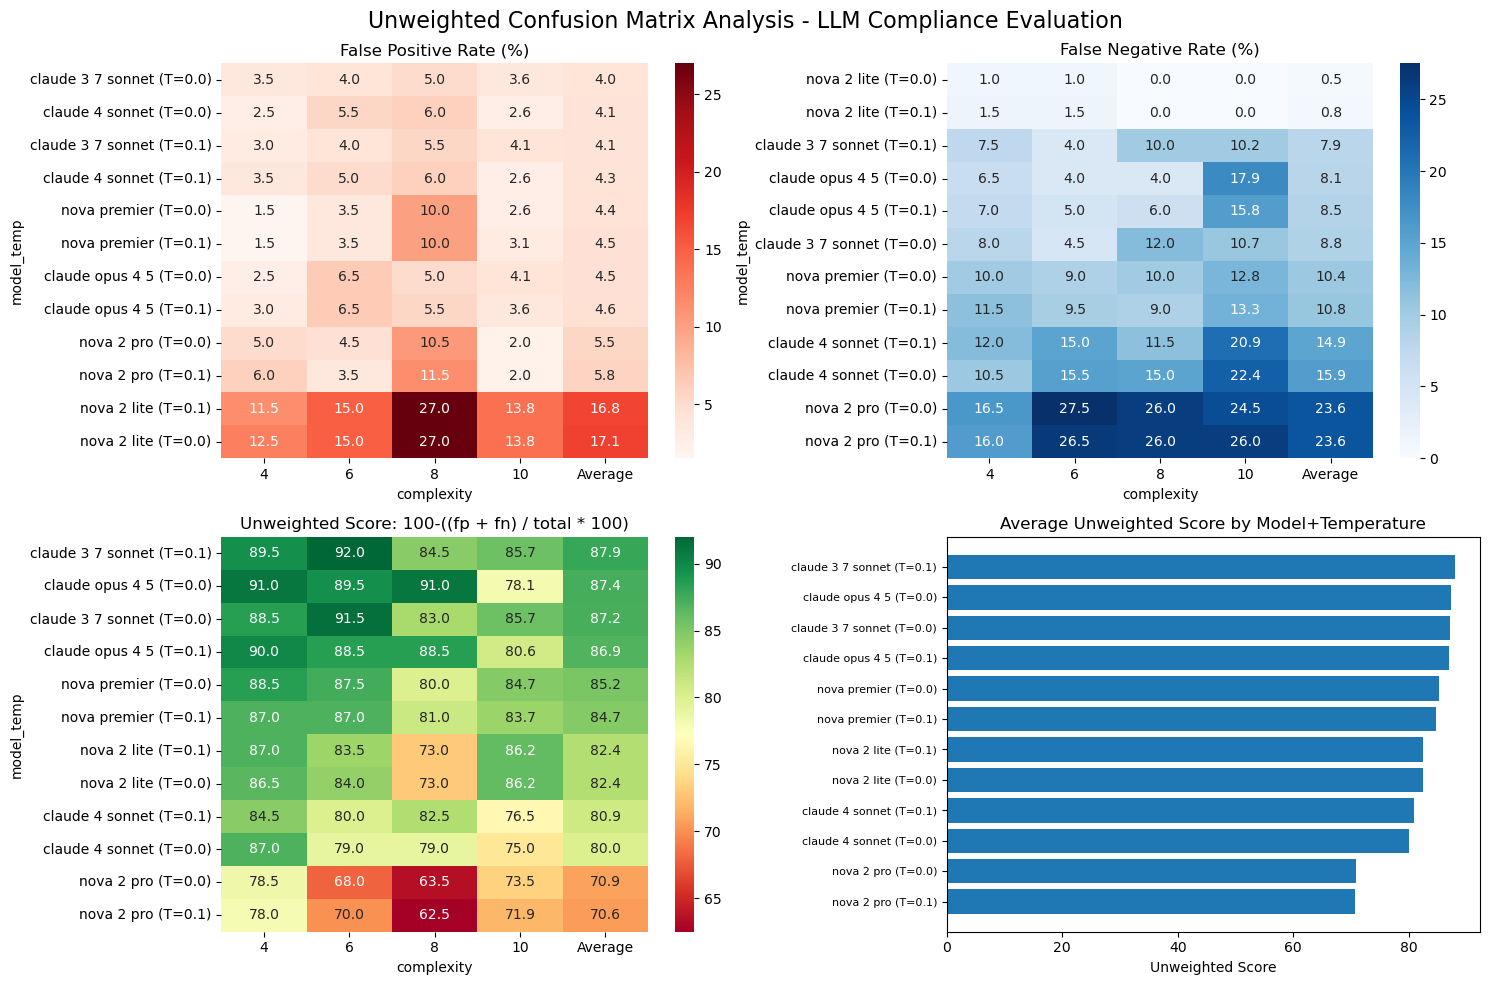


=== UNWEIGHTED SCORING SUMMARY ===
(False Positives and False Negatives weighted equally)
1. nova 2 pro (T=0.1): 70.6
2. nova 2 pro (T=0.0): 70.9
3. claude 4 sonnet (T=0.0): 80.0
4. claude 4 sonnet (T=0.1): 80.9
5. nova 2 lite (T=0.0): 82.4
6. nova 2 lite (T=0.1): 82.4
7. nova premier (T=0.1): 84.7
8. nova premier (T=0.0): 85.2
9. claude opus 4 5 (T=0.1): 86.9
10. claude 3 7 sonnet (T=0.0): 87.2
11. claude opus 4 5 (T=0.0): 87.4
12. claude 3 7 sonnet (T=0.1): 87.9
Chart saved to: images/weighted_confusion_matrix_analysis.png


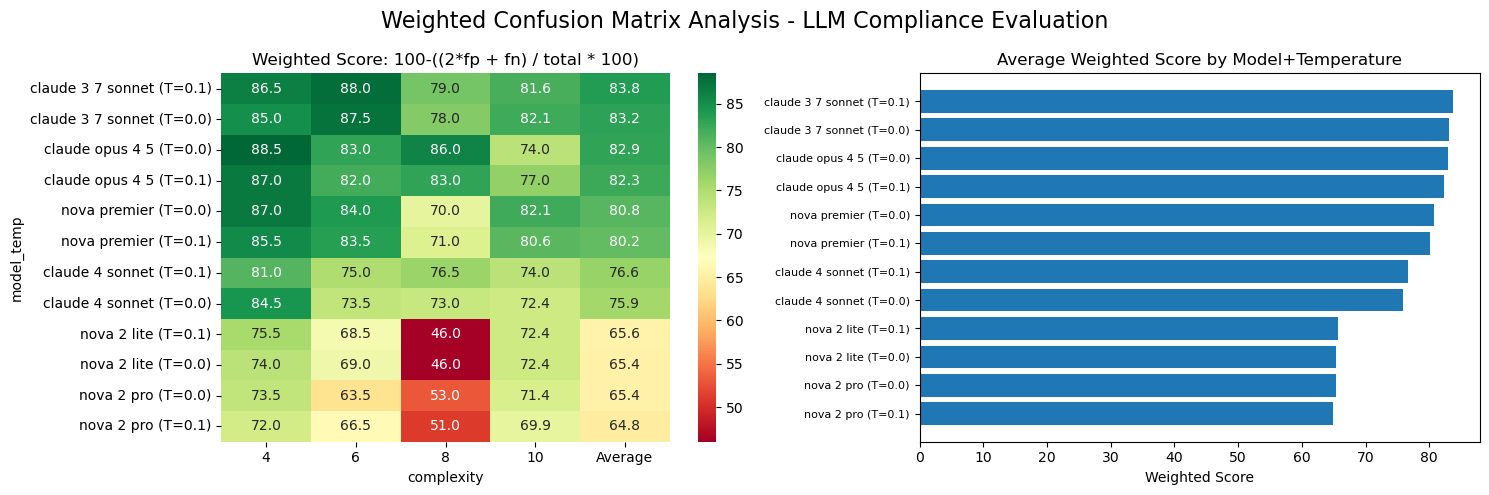


=== WEIGHTED SCORING SUMMARY ===
(False Positives penalized 2x more than False Negatives)
1. nova 2 pro (T=0.1): 64.8
2. nova 2 pro (T=0.0): 65.4
3. nova 2 lite (T=0.0): 65.4
4. nova 2 lite (T=0.1): 65.6
5. claude 4 sonnet (T=0.0): 75.9
6. claude 4 sonnet (T=0.1): 76.6
7. nova premier (T=0.1): 80.2
8. nova premier (T=0.0): 80.8
9. claude opus 4 5 (T=0.1): 82.3
10. claude opus 4 5 (T=0.0): 82.9
11. claude 3 7 sonnet (T=0.0): 83.2
12. claude 3 7 sonnet (T=0.1): 83.8
Chart saved to: images/model_performance_by_complexity.png


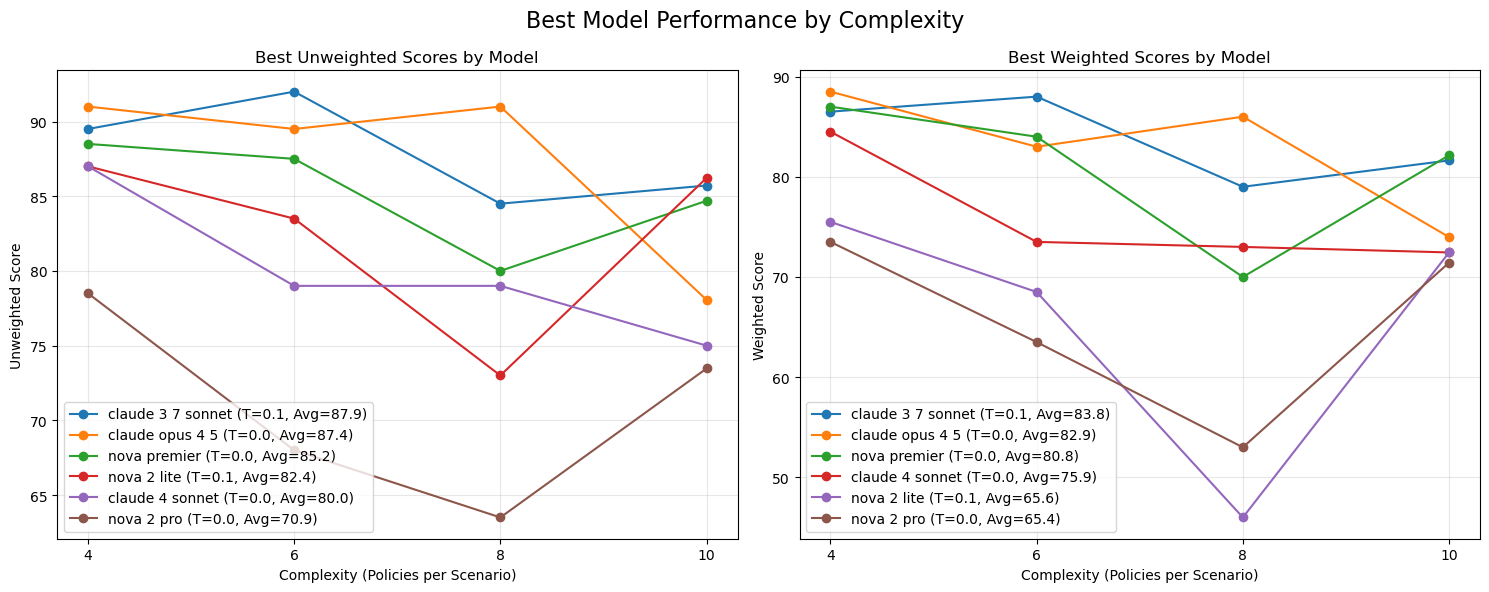


## Confusion Matrix Summary
| Model & Temp | Complexity 4 | Complexity 6 | Complexity 8 | Complexity 10 |
|---|---|---|---|---|
| **claude 3 7 sonnet** (T=0.0) | TP:89 FP:7<br>FN:16 TN:88<br>FPR:7.4% FNR:15.2%  | TP:91 FP:8<br>FN:9 TN:92<br>FPR:8.0% FNR:9.0%  | TP:76 FP:10<br>FN:24 TN:90<br>FPR:10.0% FNR:24.0%  | TP:75 FP:7<br>FN:21 TN:93<br>FPR:7.0% FNR:21.9%  |
| **claude 3 7 sonnet** (T=0.1) | TP:90 FP:6<br>FN:15 TN:89<br>FPR:6.3% FNR:14.3%  | TP:92 FP:8<br>FN:8 TN:92<br>FPR:8.0% FNR:8.0%  | TP:80 FP:11<br>FN:20 TN:89<br>FPR:11.0% FNR:20.0%  | TP:76 FP:8<br>FN:20 TN:92<br>FPR:8.0% FNR:20.8%  |
| **claude 4 sonnet** (T=0.0) | TP:84 FP:5<br>FN:21 TN:90<br>FPR:5.3% FNR:20.0%  | TP:69 FP:11<br>FN:31 TN:89<br>FPR:11.0% FNR:31.0%  | TP:70 FP:12<br>FN:30 TN:88<br>FPR:12.0% FNR:30.0%  | TP:52 FP:5<br>FN:44 TN:95<br>FPR:5.0% FNR:45.8%  |
| **claude 4 sonnet** (T=0.1) | TP:81 FP:7<br>FN:24 TN:88<br>FPR:7.4% FNR:22.9%  | TP:70 FP:10<br>FN:30 TN:90<br>FPR:10.0% FNR:30.0%  | TP:77 FP:12<br>FN:2

In [118]:
main()